In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#To not display certain errors
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r'D:\deeplearning\customer_segmentation\datasets\Train.csv')
df=df.drop(['Var_1','Segmentation'],axis=1) #Let's remove the unnecessary columns first
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0
...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 567.4 KB


In [4]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [5]:
df['AgeCat']=pd.cut(df['Age'],bins=[0, 18, 25, 35,46, 100], labels=['0-18', '19-25', '26-35', '36-46','47+'])

In [6]:
def null_values(field):
    return df[field].isnull().sum()
print("Missing Values :")
for i in df.columns:
    print(i+' : ',null_values(i))

Missing Values :
ID :  0
Gender :  0
Ever_Married :  140
Age :  0
Graduated :  78
Profession :  124
Work_Experience :  829
Spending_Score :  0
Family_Size :  335
AgeCat :  0


In [7]:
def groupby_count(df, groupby_cols, count_col, filter_cols=None):
    if filter_cols:
        df = df[filter_cols + groupby_cols + [count_col]]
    else:
        df = df[groupby_cols + [count_col]]
    return df.groupby(by=groupby_cols).count()

In [8]:
print(groupby_count(df, ['Spending_Score','Ever_Married'], 'ID') )

                               ID
Spending_Score Ever_Married      
Average        Yes           1937
High           Yes           1176
Low            No            3285
               Yes           1530


In [9]:
print(groupby_count(df, ['Profession','Ever_Married'], 'ID') )

                              ID
Profession    Ever_Married      
Artist        No             713
              Yes           1774
Doctor        No             366
              Yes            311
Engineer      No             267
              Yes            415
Entertainment No             358
              Yes            579
Executive     No              37
              Yes            550
Healthcare    No            1153
              Yes            145
Homemaker     No             112
              Yes            128
Lawyer        No              40
              Yes            575
Marketing     No             189
              Yes             96


In [10]:
print(groupby_count(df, ['AgeCat','Ever_Married'], 'ID') )

                       ID
AgeCat Ever_Married      
0-18   No             125
       Yes              4
19-25  No             771
       Yes             69
26-35  No            1360
       Yes            553
36-46  No             723
       Yes           1338
47+    No             306
       Yes           2679


In [11]:
x=df.query("Spending_Score == 'High' and Ever_Married.isna()")
x['Ever_Married']='Yes'
df.update(x)

x=df.query("Profession == 'Healthcare' and Ever_Married.isna()")
x['Ever_Married']='No'
df.update(x)

x=df.query("AgeCat == '47+' and Ever_Married.isna()")
x['Ever_Married']='Yes'
df.update(x)

x=df.query("AgeCat == '19-25' and Ever_Married.isna()")
x['Ever_Married']='No'
df.update(x)

x=df.query("AgeCat == '26-35' and Ever_Married.isna()")
x['Ever_Married']='No'
df.update(x)

In [12]:
print(null_values("Ever_Married")," We're not done yet !")

19  We're not done yet !


In [13]:
df.query("Ever_Married.isna()")['AgeCat'].unique()

['36-46']
Categories (5, str): ['0-18' < '19-25' < '26-35' < '36-46' < '47+']

In [14]:
print(groupby_count(df.query("AgeCat=='36-46'"), ['AgeCat','Profession','Ever_Married'], 'ID'))

                                    ID
AgeCat Profession    Ever_Married     
36-46  Artist        No            320
                     Yes           603
       Doctor        No             70
                     Yes           113
       Engineer      No             83
                     Yes           146
       Entertainment No            105
                     Yes           196
       Executive     No              8
                     Yes           152
       Healthcare    No             55
                     Yes            40
       Homemaker     No             30
                     Yes            40
       Lawyer        No              2
                     Yes             2
       Marketing     No             43
                     Yes            28


In [15]:
x=df.query("AgeCat=='36-46' and Ever_Married.isna() and Profession != 'Marketing'")
y=df.query("AgeCat=='36-46' and Ever_Married.isna() and Profession == 'Marketing'")

x['Ever_Married']='Yes'
y['Ever_Married']='No'

df.update(x)
df.update(y)

print(null_values('Ever_Married')," (Let's go !) ")

0  (Let's go !) 


In [16]:
print(null_values('Graduated'))

78


In [17]:
print(groupby_count(df, ['AgeCat','Graduated'], 'ID') )

                    ID
AgeCat Graduated      
0-18   No          129
       Yes           1
19-25  No          744
       Yes         110
26-35  No          844
       Yes        1086
36-46  No          485
       Yes        1582
47+    No          820
       Yes        2189


In [18]:
print(groupby_count(df, ['Profession','Graduated'], 'ID') )

                           ID
Profession    Graduated      
Artist        No          293
              Yes        2209
Doctor        No          288
              Yes         395
Engineer      No          385
              Yes         310
Entertainment No          345
              Yes         592
Executive     No          294
              Yes         300
Healthcare    No          844
              Yes         476
Homemaker     No          106
              Yes         138
Lawyer        No          230
              Yes         381
Marketing     No          173
              Yes         114


In [19]:
print(groupby_count(df, ['Ever_Married','Graduated'], 'ID') )

                          ID
Ever_Married Graduated      
No           No         1622
             Yes        1677
Yes          No         1400
             Yes        3291


In [20]:
x=df.query("(AgeCat=='0-18' or AgeCat=='19-25') and Graduated.isna()")
x['Graduated']='No'
df.update(x)

x=df.query("Profession=='Artist' and Graduated.isna()")
x['Graduated']='Yes'
df.update(x)

x=df.query("(AgeCat=='47+') and Graduated.isna()")
x['Graduated']='Yes'
df.update(x)

x=df.query("Ever_Married=='Yes' and Graduated.isna()")
x['Graduated']='Yes'
df.update(x)

In [21]:
print(null_values('Graduated')," Let's drop the rest !")

14  Let's drop the rest !


In [22]:
df=df.drop(df.query("Graduated.isna()").index)

In [23]:
null_values("Profession")

np.int64(122)

<Axes: xlabel='Profession', ylabel='count'>

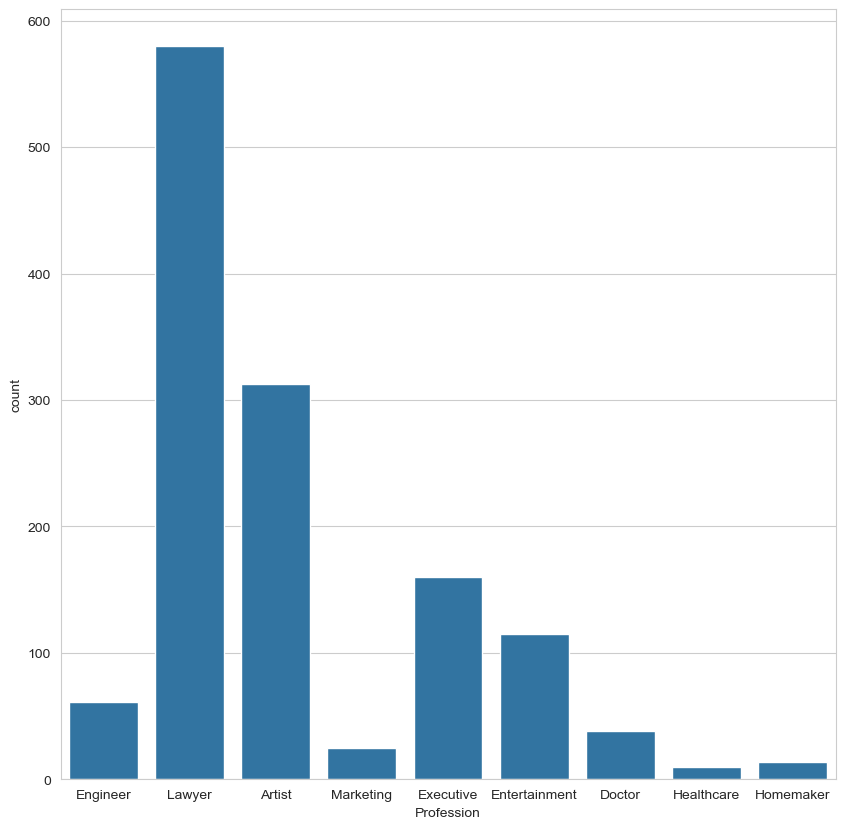

In [24]:
x=df.query("Age>60")
plt.figure(figsize=(10,10))
sns.countplot(x[["Profession"]],x="Profession")

In [25]:
print(groupby_count(x, ['Spending_Score','Profession'], 'ID') )

                               ID
Spending_Score Profession        
Average        Artist         127
               Doctor          17
               Engineer        20
               Entertainment   50
               Executive        7
               Healthcare       3
               Homemaker        3
               Lawyer          16
               Marketing        3
High           Artist          77
               Doctor           6
               Engineer        13
               Entertainment   16
               Executive      120
               Homemaker        3
               Lawyer         304
               Marketing        7
Low            Artist         109
               Doctor          15
               Engineer        28
               Entertainment   49
               Executive       33
               Healthcare       7
               Homemaker        8
               Lawyer         260
               Marketing       15


In [26]:
x=df.query("Age>60 and Profession.isna() and Spending_Score=='Average'")
x['Profession']='Artist'
df.update(x)

x=df.query("Age>60 and Profession.isna() and (Spending_Score=='Low' or Spending_Score=='High')")
x['Profession']='Lawyer'
df.update(x)

In [27]:
x=df.query("Graduated=='Yes' and Profession.isna()")
x['Profession']='Artist'
df.update(x) ##Remember ! Most Artists are graduated

In [28]:
print(groupby_count(df, ['AgeCat','Profession'], 'ID') )

                        ID
AgeCat Profession         
0-18   Artist            2
       Doctor            9
       Entertainment     5
       Executive         3
       Healthcare      105
       Marketing         5
19-25  Artist           42
       Doctor           81
       Engineer         40
       Entertainment    51
       Executive        17
       Healthcare      542
       Homemaker        14
       Lawyer            3
       Marketing        62
26-35  Artist          402
       Doctor          265
       Engineer        192
       Entertainment   239
       Executive        66
       Healthcare      551
       Homemaker       111
       Lawyer            2
       Marketing        89
36-46  Artist          949
       Doctor          186
       Engineer        233
       Entertainment   301
       Executive       161
       Healthcare       95
       Homemaker        71
       Lawyer            4
       Marketing        71
47+    Artist         1177
       Doctor          145
 

In [29]:
x=df.query("(AgeCat=='0-18' or AgeCat=='19-25') and Profession.isna()")
x['Profession']='Healthcare'
df.update(x)

x=df.query("Age>47 and Age<60 and Profession.isna()")
x['Profession']="Artist"
df.update(x)


In [30]:
print(groupby_count(df, ['Ever_Married','Profession'], 'ID') )

                              ID
Ever_Married Profession         
No           Artist          730
             Doctor          368
             Engineer        269
             Entertainment   355
             Executive        37
             Healthcare     1194
             Homemaker       115
             Lawyer           43
             Marketing       188
Yes          Artist         1851
             Doctor          318
             Engineer        429
             Entertainment   590
             Executive       562
             Healthcare      153
             Homemaker       131
             Lawyer          592
             Marketing       101


In [31]:
x=df.query("Ever_Married=='Yes' and Profession.isna()")
x['Profession']="Artist"
df.update(x)

x=df.query("Ever_Married=='No' and Profession.isna()")
x['Profession']="Healthcare"
df.update(x)

In [32]:
null_values("Profession")

np.int64(0)

In [33]:
null_values("Work_Experience")

np.int64(828)

In [34]:
df['Work_Experience'].describe(percentiles=[i*0.1 for i in range(10)])

count    7226.000000
mean        2.637697
std         3.405054
min         0.000000
0%          0.000000
10%         0.000000
20%         0.000000
30%         0.000000
40%         1.000000
50%         1.000000
60%         1.000000
70%         3.000000
80%         6.000000
90%         8.000000
max        14.000000
Name: Work_Experience, dtype: float64

In [35]:
df['Work_Experience'] = df['Work_Experience'].ffill()

In [36]:
df['Work_Experience'].describe(percentiles=[i*0.1 for i in range(10)])

count    8054.000000
mean        2.613236
std         3.391398
min         0.000000
0%          0.000000
10%         0.000000
20%         0.000000
30%         0.000000
40%         1.000000
50%         1.000000
60%         1.000000
70%         3.000000
80%         6.000000
90%         8.000000
max        14.000000
Name: Work_Experience, dtype: float64

In [37]:
null_values("Family_Size")

np.int64(333)

In [38]:
df['Family_Size'].describe(percentiles=[i*0.1 for i in range(10)])

count    7721.000000
mean        2.849631
std         1.529351
min         1.000000
0%          1.000000
10%         1.000000
20%         2.000000
30%         2.000000
40%         2.000000
50%         3.000000
60%         3.000000
70%         4.000000
80%         4.000000
90%         5.000000
max         9.000000
Name: Family_Size, dtype: float64

In [39]:
df['Family_Size'] = df['Family_Size'].ffill()

In [40]:
df['Family_Size'].describe(percentiles=[i*0.1 for i in range(10)])

count    8054.000000
mean        2.846288
std         1.528556
min         1.000000
0%          1.000000
10%         1.000000
20%         2.000000
30%         2.000000
40%         2.000000
50%         3.000000
60%         3.000000
70%         4.000000
80%         4.000000
90%         5.000000
max         9.000000
Name: Family_Size, dtype: float64

In [41]:
for i in df.columns:
    print(i+' : ',null_values(i))

ID :  0
Gender :  0
Ever_Married :  0
Age :  0
Graduated :  0
Profession :  0
Work_Experience :  0
Spending_Score :  0
Family_Size :  0
AgeCat :  0


In [42]:
original_df=df
df=df.drop(labels=['ID','AgeCat'],axis=1)
L=list(df['Profession'].unique())

In [43]:
L

['Healthcare',
 'Engineer',
 'Lawyer',
 'Entertainment',
 'Artist',
 'Executive',
 'Doctor',
 'Homemaker',
 'Marketing']

one-hot encoding

In [44]:
df

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,Male,No,22,No,Healthcare,1.0,Low,4.0
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0
4,Female,Yes,40,Yes,Entertainment,0.0,High,6.0
...,...,...,...,...,...,...,...,...
8063,Male,No,22,No,Healthcare,0.0,Low,7.0
8064,Male,No,35,No,Executive,3.0,Low,4.0
8065,Female,No,33,Yes,Healthcare,1.0,Low,1.0
8066,Female,No,27,Yes,Healthcare,1.0,Low,4.0


In [45]:
df_ohe = pd.get_dummies(df)

PCA

In [46]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df_ohe)

In [48]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

In [49]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=df_ohe.columns
)

print(loadings)

                               PC1       PC2
Age                      -0.345535  0.008484
Work_Experience           0.055174 -0.098139
Family_Size               0.085063  0.215860
Gender_Female             0.068917 -0.416392
Gender_Male              -0.068917  0.416392
Ever_Married_No           0.430515 -0.087904
Ever_Married_Yes         -0.430515  0.087904
Graduated_No              0.219766  0.380165
Graduated_Yes            -0.219766 -0.380165
Profession_Artist        -0.159362 -0.299109
Profession_Doctor         0.051155 -0.000638
Profession_Engineer       0.025508 -0.062329
Profession_Entertainment -0.009966  0.071174
Profession_Executive     -0.113643  0.314803
Profession_Healthcare     0.284639  0.121428
Profession_Homemaker      0.025622 -0.089390
Profession_Lawyer        -0.139630  0.070148
Profession_Marketing      0.067101  0.015500
Spending_Score_Average   -0.245676 -0.057220
Spending_Score_High      -0.215140  0.225056
Spending_Score_Low        0.373564 -0.114427


In [68]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)

print(explained)
print(cum_var)

[2.02539173e-01 1.17737386e-01 9.79159513e-02 8.51272795e-02
 6.27907124e-02 5.81213495e-02 5.27621452e-02 5.11364662e-02
 5.02478116e-02 4.73718704e-02 4.03835971e-02 3.92913223e-02
 3.06880124e-02 2.64616106e-02 2.42460373e-02 1.31792746e-02
 6.16574289e-17 2.70928186e-17 9.71528603e-18 2.13141024e-18
 0.00000000e+00]
[0.20253917 0.32027656 0.41819251 0.50331979 0.5661105  0.62423185
 0.676994   0.72813046 0.77837828 0.82575015 0.86613374 0.90542507
 0.93611308 0.96257469 0.98682073 1.         1.         1.
 1.         1.         1.        ]


回到 k-prototype

轉換成數值

In [50]:
df['Profession']=df['Profession'].apply(lambda x:L.index(x)+1 )


df['Ever_Married']=df['Ever_Married'].replace(('Yes','No'),(1,0))
df['Graduated']=df['Graduated'].replace(('Yes','No'),(1,0))
df['Gender']=df['Gender'].replace(('Male','Female'),(1,0))

In [51]:
L=list(df['Spending_Score'].unique())

In [52]:
L

['Low', 'Average', 'High']

In [53]:
df['Spending_Score']=df['Spending_Score'].apply(lambda x:L.index(x)+1 )

df.head(5)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,1,0,22,0,1,1.0,1,4.0
1,0,1,38,1,2,1.0,2,3.0
2,0,1,67,1,2,1.0,1,1.0
3,1,1,67,1,3,0.0,3,2.0
4,0,1,40,1,4,0.0,3,6.0


In [54]:
from kmodes.kprototypes import KPrototypes

In [55]:
df.head(2)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,1,0,22,0,1,1.0,1,4.0
1,0,1,38,1,2,1.0,2,3.0


In [56]:
categorical_features_idx=[0,1,3,4,5,6] #Categorical columns of our dataset
mark_array=df.values

分成三組

In [57]:
kproto = KPrototypes(n_clusters=3, init='Cao', verbose=0)
clusters = kproto.fit_predict(mark_array, categorical=categorical_features_idx)

In [58]:

df['cluster'] = list(clusters)
df['Profession']=original_df['Profession']
df['Gender']=original_df['Gender']
df['Ever_Married']=original_df['Ever_Married']
df['Graduated']=original_df['Graduated']
df['Spending_Score']=original_df['Spending_Score']
df['ID']=original_df['ID']

In [63]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 建立資料夾
os.makedirs(r"D:\deeplearning\customer_segmentation\images", exist_ok=True)

for i in [0,1,2]:
    plt.figure(figsize=(20,15))

    subset = df.query("cluster==" + str(i))

    sns.countplot(data=subset, x="Profession")
    plt.title("Cluster " + str(i+1))

    # ⭐ 這裡是你要加的
    plt.tight_layout()

    filename = f"images/Profession_Cluster_{i+1}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.close()

In [64]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 建立資料夾
os.makedirs(r"D:\deeplearning\customer_segmentation\images", exist_ok=True)

# ===== 1️⃣ Ever Married =====
for i in [0,1,2]:
    plt.figure(figsize=(8,6))

    data = df.query("cluster==" + str(i))["Ever_Married"].value_counts()

    plt.pie(data, labels=data.index, autopct='%1.1f%%')
    plt.title('Ever Married - Cluster ' + str(i+1))

    plt.tight_layout()
    filename = f"images/Ever_Married_Cluster_{i+1}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()


# ===== 2️⃣ Graduated =====
for i in [0,1,2]:
    plt.figure(figsize=(8,6))

    data = df.query("cluster==" + str(i))["Graduated"].value_counts()

    plt.pie(data, labels=data.index, autopct='%1.1f%%')
    plt.title('Graduated - Cluster ' + str(i+1))

    plt.tight_layout()
    filename = f"images/Graduated_Cluster_{i+1}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()


# ===== 3️⃣ Spending Score =====
for i in [0,1,2]:
    plt.figure(figsize=(8,6))

    data = df.query("cluster==" + str(i))["Spending_Score"].value_counts()

    plt.pie(data, labels=data.index, autopct='%1.1f%%')
    plt.title('Spending Score - Cluster ' + str(i+1))

    plt.tight_layout()
    filename = f"images/Spending_Score_Cluster_{i+1}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()


# ===== 4️⃣ Family Size (countplot) =====
for i in [0,1,2]:
    plt.figure(figsize=(8,6))

    subset = df.query("cluster==" + str(i))

    sns.countplot(data=subset, x="Family_Size")
    plt.title('Family Size - Cluster ' + str(i+1))

    plt.tight_layout()
    filename = f"images/Family_Size_Cluster_{i+1}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

In [60]:
print(df[['cluster','Age']].groupby(by=['cluster']).mean())

               Age
cluster           
0        45.747475
1        27.900285
2        70.702420


In [61]:
df.groupby("cluster").mean(numeric_only=True)

,Age,Work_Experience,Family_Size,ID
cluster,,,,
0,45.747475,2.675876,2.693999,463521.621509
1,27.900285,3.089585,3.282684,463454.438113
2,70.702420,1.491171,2.279922,463426.886854


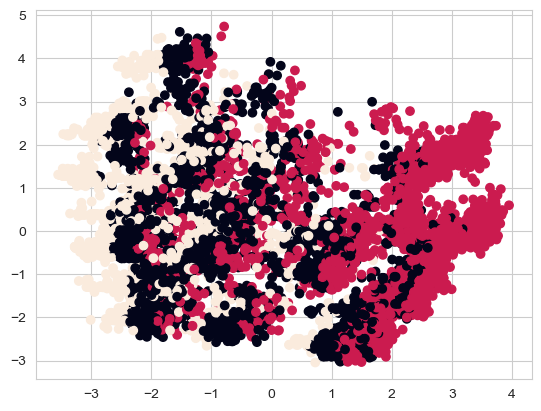

In [62]:
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=df["cluster"])

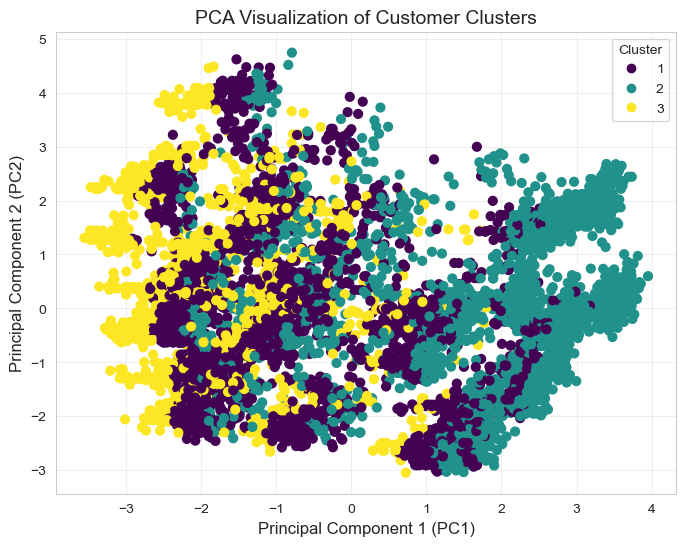

In [66]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    c=df["cluster"],
    cmap="viridis",
    s=40
)

# X / Y label
plt.xlabel("Principal Component 1 (PC1)", fontsize=12)
plt.ylabel("Principal Component 2 (PC2)", fontsize=12)

# Title
plt.title("PCA Visualization of Customer Clusters", fontsize=14)

# Cluster legend (+1)
handles, _ = scatter.legend_elements()

cluster_labels = np.sort(df["cluster"].unique())
labels = [str(i + 1) for i in cluster_labels]

plt.legend(handles, labels, title="Cluster")

plt.grid(True, alpha=0.3)
plt.show()

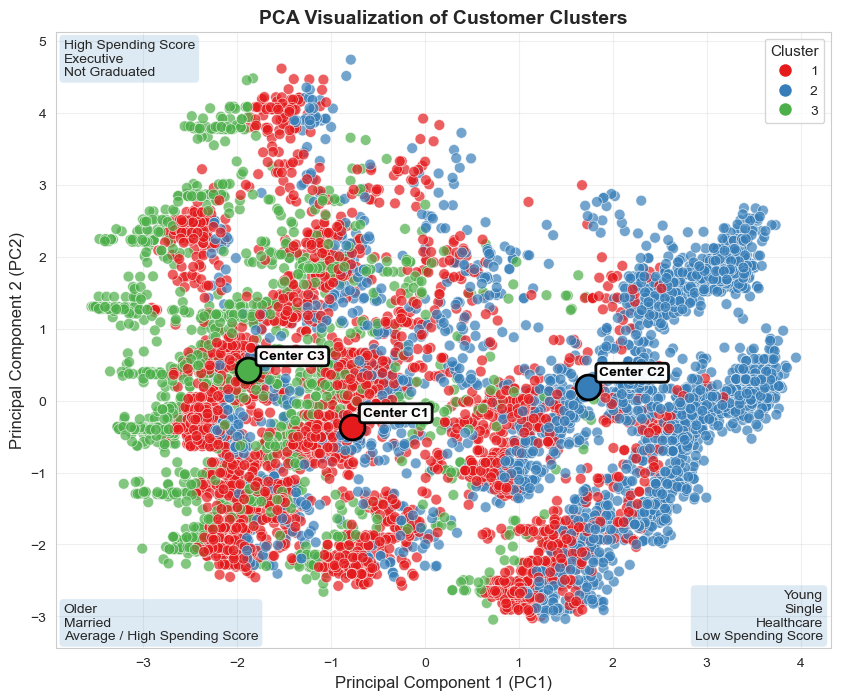

Saved to: D:\deeplearning\customer_segmentation\images\PCA\pca_customer_clusters_enhanced.png


In [73]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# =========================
# Save path
# =========================
save_path = r"D:\deeplearning\customer_segmentation\images\PCA"
os.makedirs(save_path, exist_ok=True)

file_path = os.path.join(save_path, "pca_customer_clusters_enhanced.png")

# =========================
# Custom colors
# =========================
cluster_colors = {
    0: "#e41a1c",   # red
    1: "#377eb8",   # blue
    2: "#4daf4a"    # green
}

point_colors = df["cluster"].map(cluster_colors)

# =========================
# Plot
# =========================
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    c=point_colors,
    s=60,
    alpha=0.70,
    edgecolors="white",
    linewidths=0.5
)

# Labels
plt.xlabel("Principal Component 1 (PC1)", fontsize=12)
plt.ylabel("Principal Component 2 (PC2)", fontsize=12)
plt.title("PCA Visualization of Customer Clusters", fontsize=14, weight="bold")

# =========================
# Legend
# =========================
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='1',
           markerfacecolor=cluster_colors[0], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='2',
           markerfacecolor=cluster_colors[1], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='3',
           markerfacecolor=cluster_colors[2], markersize=10)
]

plt.legend(
    handles=legend_elements,
    title="Cluster",
    loc="upper right",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

# =========================
# Cluster centers
# =========================
center_df = pd.DataFrame({
    "PC1": X_pca_2[:,0],
    "PC2": X_pca_2[:,1],
    "cluster": df["cluster"]
})

centers = center_df.groupby("cluster")[["PC1","PC2"]].mean()

for idx, row in centers.iterrows():

    center_color = cluster_colors[idx]

    # center 點（跟 cluster 同色）
    plt.scatter(
        row["PC1"],
        row["PC2"],
        s=320,
        color=center_color,
        edgecolors="black",
        linewidths=2,
        zorder=6
    )

    # center 標籤
    plt.annotate(
        f"Center C{idx+1}",
        (row["PC1"], row["PC2"]),
        xytext=(8,8),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",     # 白底
            ec="black",     # 黑框（改這裡）
            lw=2,
            alpha=0.95
        ),
        zorder=7
    )

# =========================
# Grid
# =========================
plt.grid(True, alpha=0.3)

# Axis range
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# =========================
# PCA meaning notes
# =========================
plt.text(
    x_max*0.98, y_min*0.98,
    "Young\nSingle\nHealthcare\nLow Spending Score",
    ha="right", va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
)

plt.text(
    x_min*0.98, y_min*0.98,
    "Older\nMarried\nAverage / High Spending Score",
    ha="left", va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
)

plt.text(
    x_min*0.98, y_max*0.98,
    "High Spending Score\nExecutive\nNot Graduated",
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
)

# Save
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", file_path)

In [ ]:
# cost = []
# for k in range(2, 8):
#     kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0)
#     kproto.fit(mark_array, categorical=categorical_features_idx)
#     cost.append(kproto.cost_)

In [ ]:
# cost

In [ ]:
# import os
# import pandas as pd
#
# # 資料夾路徑
# save_path = r"D:\deeplearning\customer_segmentation\images\k prototype"
# os.makedirs(save_path, exist_ok=True)
#
# # 建立 cost DataFrame
# k_values = list(range(2, 8))
#
# cost_df = pd.DataFrame({
#     "k": k_values,
#     "cost": cost
# })
#
# # 存 CSV
# csv_path = os.path.join(save_path, "kprototype_cost.csv")
# cost_df.to_csv(csv_path, index=False)
#
# print("Saved to:", csv_path)
# print(cost_df)

In [ ]:
# import os
# import matplotlib.pyplot as plt
#
# # 資料夾路徑
# save_path = r"D:\deeplearning\customer_segmentation\images\k prototype"
# os.makedirs(save_path, exist_ok=True)
#
# # 檔案完整路徑
# file_path = os.path.join(save_path, "kprototype_elbow.png")
#
# # k values
# k_values = range(2, 8)
#
# # 畫圖
# plt.figure(figsize=(8,5))
# plt.plot(k_values, cost, marker='o', linewidth=2)
#
# # 標示數值
# for k, c in zip(k_values, cost):
#     plt.text(k, c, f"{c:,.0f}", ha='center', va='bottom', fontsize=9)
#
# plt.xticks(k_values)
# plt.xlabel("Number of Clusters (k)")
# plt.ylabel("Cost")
# plt.title("Elbow Method for K-Prototypes")
# plt.grid(True, alpha=0.3)
#
# # 存圖
# plt.savefig(file_path, dpi=300, bbox_inches="tight")
#
# # 顯示
# plt.show()
#
# print("Saved to:", file_path)